In [1]:
import importlib
import solution
importlib.reload(solution)
from solution import PolynomialFeatures
from sklearn.linear_model import Ridge as SklearnRidge

In [2]:
from solution import PolynomialFeatures
import numpy as np

# Test 1 — shape check with 2 features
X_test = np.random.randn(100, 2)
pf = PolynomialFeatures(degree=2)
X_out = pf.fit_transform(X_test)
print(X_out.shape)  # expect (100, 5) → 2 + 2 + 1

(100, 5)


In [3]:
X_test = np.random.randn(100, 2)
pf2 = PolynomialFeatures(degree=2)
pf3 = PolynomialFeatures(degree=3)

print(pf2.fit_transform(X_test).shape)  # expect (100, 5)
print(pf3.fit_transform(X_test).shape)  # expect (100, 7)

(100, 5)
(100, 7)


In [4]:
import importlib
import solution
importlib.reload(solution)
from solution import PolynomialRegression
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv('data/hour.csv')
features = ['atemp', 'hum', 'windspeed', 'hr', 'season', 'workingday']
target = 'cnt'

X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Test degree 2
model = PolynomialRegression(degree=2)
model.fit(X_train, y_train)

print("Train R²:", model.score(X_train, y_train))
print("Test  R²:", model.score(X_test, y_test))

Train R²: 0.4807465108365928
Test  R²: 0.47358678619995087


### Understanding R² in Model Performance (Bike Rentals Example)

#### What is R²?

R² (R-squared) answers one of the most important questions in machine learning:

> **How much of the variance in the target variable (bike rentals) does our model explain?**

In simpler terms, it tells us how well our model captures the patterns in the data.

---

####  Interpreting R² Values

| R² Value | Meaning                                                      |
| -------- | ------------------------------------------------------------ |
| **1.0**  | Perfect predictions — the model explains all variability     |
| **0.48** | The model explains 48% of the variance                       |
| **0.0**  | No predictive power — same as predicting the mean every time |

---

####  Our Current Model Results

* **Train R²:** 0.48
* **Test R²:** 0.47

---

####  What These Numbers Tell Us

##### 1.  No Overfitting

* The training and testing scores are almost identical.
* This means our model is **generalizing well** to unseen data.
* No signs of memorizing the training set.

> ✔️ *Good news:* Our model is stable.

---

##### 2.  Underfitting Problem

* An R² of ~0.48 is relatively low.
* Our model is only capturing **less than half of the underlying patterns**.
* This suggests the model is **too simple**.

In our case:

> A **degree=2 polynomial (parabola)** isn’t flexible enough to model relationships across **6 features**.

---

####  Why This Matters

A model that underfits:

* Misses important relationships
* Produces weaker predictions
* Leaves useful signal unexplained

---

####  What We Do Next

This is exactly why we run a **degree experiment**.

##### Goal:

Find the **sweet spot** where:

* R² is **high** (model captures more patterns)
* Train and Test R² remain **close** (no overfitting)

---

*We’re not debugging — we’re tuning intelligence.*


## The Degree Experiment

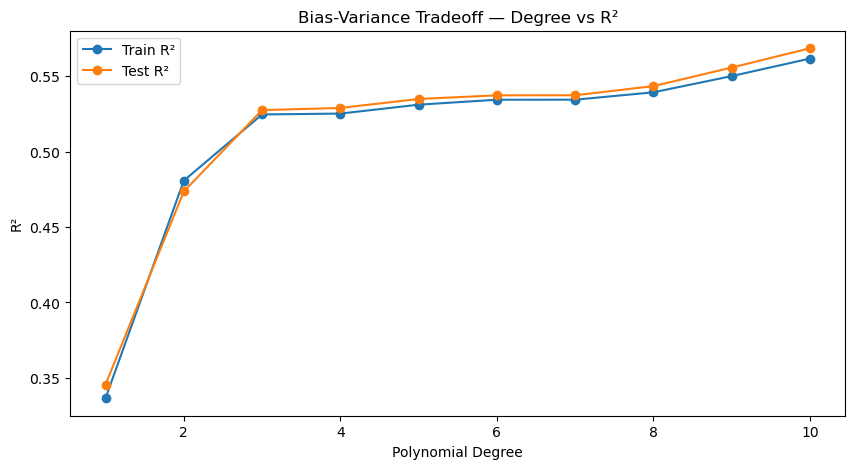

Degree  1 → Train R²: 0.3365 | Test R²: 0.3456
Degree  2 → Train R²: 0.4807 | Test R²: 0.4736
Degree  3 → Train R²: 0.5246 | Test R²: 0.5275
Degree  4 → Train R²: 0.5252 | Test R²: 0.5289
Degree  5 → Train R²: 0.5311 | Test R²: 0.5349
Degree  6 → Train R²: 0.5344 | Test R²: 0.5373
Degree  7 → Train R²: 0.5344 | Test R²: 0.5374
Degree  8 → Train R²: 0.5393 | Test R²: 0.5434
Degree  9 → Train R²: 0.5501 | Test R²: 0.5557
Degree 10 → Train R²: 0.5617 | Test R²: 0.5685


In [5]:
import matplotlib.pyplot as plt

degrees = range(1, 11)
train_scores = []
test_scores = []

for degree in degrees:
    model = PolynomialRegression(degree=degree)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(degrees, train_scores, marker='o', label='Train R²')
plt.plot(degrees, test_scores, marker='o', label='Test R²')
plt.xlabel('Polynomial Degree')
plt.ylabel('R²')
plt.title('Bias-Variance Tradeoff — Degree vs R²')
plt.legend()
plt.savefig('results/degree_experiment.png', dpi=150)
plt.show()

for d, tr, te in zip(degrees, train_scores, test_scores):
    print(f"Degree {d:2d} → Train R²: {tr:.4f} | Test R²: {te:.4f}")

### Fitted Curves Comparison

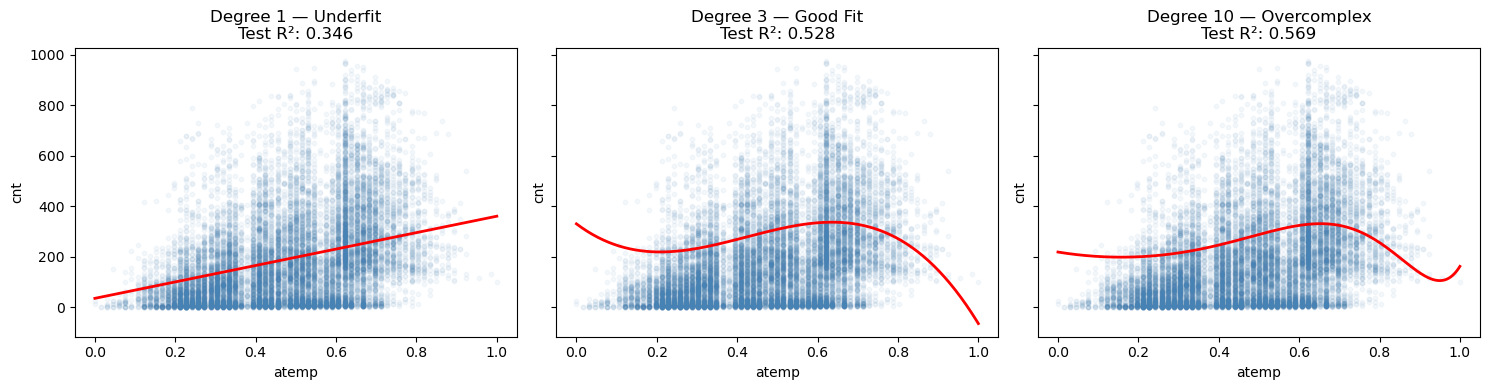

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
degrees_to_plot = [1, 3, 10]
titles = ['Degree 1 — Underfit', 'Degree 3 — Good Fit', 'Degree 10 — Overcomplex']

atemp_idx = 0  # atemp is first feature
atemp_range = np.linspace(X_train[:, atemp_idx].min(),
                          X_train[:, atemp_idx].max(), 300)

# Build a synthetic X where only atemp varies, others fixed at mean
X_mean = X_train.mean(axis=0)

for ax, degree, title in zip(axes, degrees_to_plot, titles):
    # Build input with atemp varying, all other features at mean
    X_line = np.tile(X_mean, (300, 1))
    X_line[:, atemp_idx] = atemp_range

    model = PolynomialRegression(degree=degree)
    model.fit(X_train, y_train)
    y_line = model.predict(X_line)

    ax.scatter(X_train[:, atemp_idx], y_train, alpha=0.05, s=10, color='steelblue')
    ax.plot(atemp_range, y_line, color='red', linewidth=2)
    ax.set_title(f'{title}\nTest R²: {model.score(X_test, y_test):.3f}')
    ax.set_xlabel('atemp')
    ax.set_ylabel('cnt')

plt.tight_layout()
plt.savefig('results/fitted_curves_comparison.png', dpi=150)
plt.show()

### Cross Validation Cell

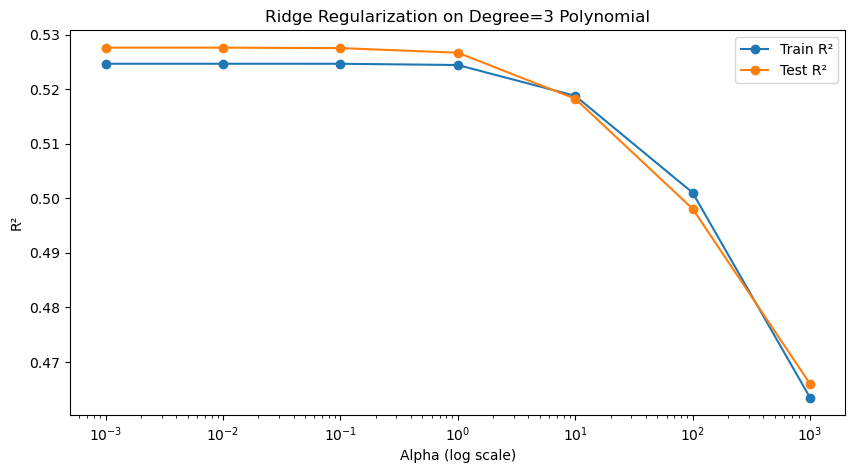

Alpha    0.001 → Train R²: 0.5246 | Test R²: 0.5276
Alpha     0.01 → Train R²: 0.5246 | Test R²: 0.5276
Alpha      0.1 → Train R²: 0.5246 | Test R²: 0.5275
Alpha        1 → Train R²: 0.5244 | Test R²: 0.5267
Alpha       10 → Train R²: 0.5188 | Test R²: 0.5182
Alpha      100 → Train R²: 0.5010 | Test R²: 0.4981
Alpha     1000 → Train R²: 0.4634 | Test R²: 0.4660


In [8]:
from sklearn.linear_model import Ridge
from solution import PolynomialFeatures, StandardScaler

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_scores = []
test_scores = []

for alpha in alphas:
    poly = PolynomialFeatures(degree=3)
    scaler = StandardScaler()
    
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.fit_transform(X_test)
    
    X_train_scaled = scaler.fit_transform(X_train_poly)
    X_test_scaled = scaler.transform(X_test_poly)
    
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)
    
    train_scores.append(model.score(X_train_scaled, y_train))
    test_scores.append(model.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 5))
plt.plot(alphas, train_scores, marker='o', label='Train R²')
plt.plot(alphas, test_scores, marker='o', label='Test R²')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R²')
plt.title('Ridge Regularization on Degree=3 Polynomial')
plt.legend()
plt.savefig('results/ridge_on_polynomial.png', dpi=150)
plt.show()

for a, tr, te in zip(alphas, train_scores, test_scores):
    print(f"Alpha {a:8} → Train R²: {tr:.4f} | Test R²: {te:.4f}")

In [9]:
from sklearn.linear_model import RidgeCV

poly = PolynomialFeatures(degree=3)
scaler = StandardScaler()

X_train_poly = scaler.fit_transform(poly.fit_transform(X_train))
X_test_poly = scaler.transform(poly.fit_transform(X_test))

alphas_to_try = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_cv = RidgeCV(alphas=alphas_to_try, cv=5)
ridge_cv.fit(X_train_poly, y_train)

print(f"Best alpha (5-fold CV): {ridge_cv.alpha_}")
print(f"Test R²: {ridge_cv.score(X_test_poly, y_test):.4f}")

Best alpha (5-fold CV): 0.1
Test R²: 0.5275
